In [5]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os

print(f"Current Directory: {os.getcwd()}")
TRAIN_CLEAN_PATH = "../data/train_clean.csv"
TEST_CLEAN_PATH = "../data/test_clean.csv"

# Load data bersih hasil notebook 1
train_clean = pd.read_csv(TRAIN_CLEAN_PATH)
test_clean = pd.read_csv(TEST_CLEAN_PATH)

# Pisahkan fitur (X) dan target/label (y)
X_train = train_clean.drop(['target'], axis=1)
y_train = train_clean['target']

X_test = test_clean.drop(['target'], axis=1)
y_test = test_clean['target']

print(f"Data Siap Diadu!")
print(f"Fitur Latih: {X_train.shape}, Label Latih: {y_train.shape}")
print(f"Fitur Uji: {X_test.shape}, Label Uji: {y_test.shape}")

Current Directory: d:\Tubes ML (2)\notebooks
Data Siap Diadu!
Fitur Latih: (7352, 561), Label Latih: (7352,)
Fitur Uji: (2947, 561), Label Uji: (2947,)


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. Inisialisasi 4 Model Sekaligus
models = {
    "K-Nearest Neighbors (Baseline)": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine (Baseline)": SVC(kernel='rbf', probability=True, random_state=42),
    "Random Forest (Advanced Ensemble)": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost (Advanced Ensemble)": XGBClassifier(eval_metric='mlogloss', random_state=42)
}

# Tempat menyimpan hasil evaluasi
accuracy_results = {}
stored_predictions = {}

# 2. Looping Otomatis: Training & Evaluasi Dasar
for name, model in models.items():
    print(f"🔄 Sedang melatih model: {name}...")
    
    # Proses Training
    model.fit(X_train, y_train)
    
    # Proses Prediksi ke Data Uji
    y_pred = model.predict(X_test)
    stored_predictions[name] = y_pred
    
    # Hitung Akurasi
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc
    print(f"✅ Akurasi {name}: {acc*100:.2f}%\n")

print("🏆 Semua model selesai ditandingkan!")

🔄 Sedang melatih model: K-Nearest Neighbors (Baseline)...
✅ Akurasi K-Nearest Neighbors (Baseline): 90.02%

🔄 Sedang melatih model: Support Vector Machine (Baseline)...
✅ Akurasi Support Vector Machine (Baseline): 95.05%

🔄 Sedang melatih model: Random Forest (Advanced Ensemble)...
✅ Akurasi Random Forest (Advanced Ensemble): 92.60%

🔄 Sedang melatih model: XGBoost (Advanced Ensemble)...
✅ Akurasi XGBoost (Advanced Ensemble): 93.79%

🏆 Semua model selesai ditandingkan!


C:\Users\ACER\AppData\Local\Temp\ipykernel_26984\487977147.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Accuracy', y='Model', data=df_results, palette='Blues_r')


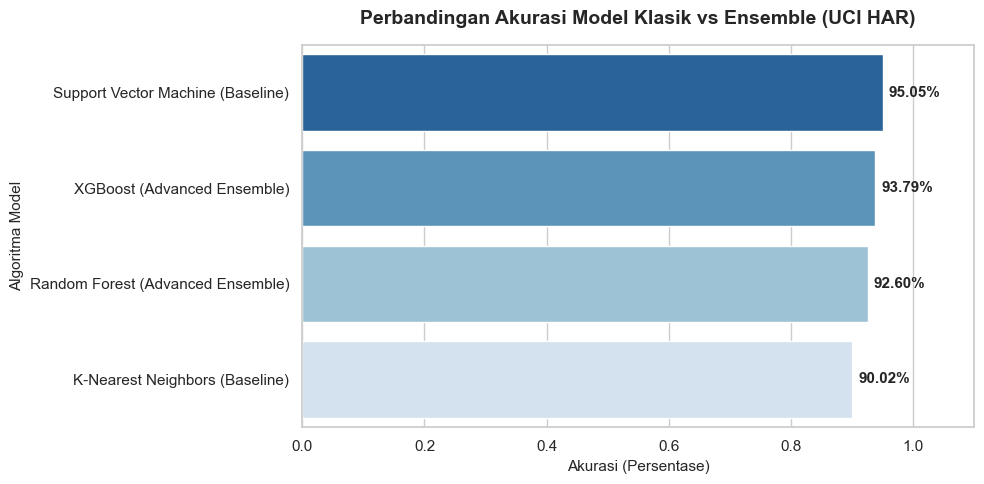

In [10]:
# Convert hasil ke DataFrame agar mudah di-plot
df_results = pd.DataFrame(list(accuracy_results.items()), columns=['Model', 'Accuracy'])
df_results = df_results.sort_values(by='Accuracy', ascending=False)

# Setup tema visualisasi
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Plot grafik batang
ax = sns.barplot(x='Accuracy', y='Model', data=df_results, palette='Blues_r')
plt.title('Perbandingan Akurasi Model Klasik vs Ensemble (UCI HAR)', fontsize=14, fontweight='bold', pad=15)
plt.xlim(0, 1.1)
plt.xlabel('Akurasi (Persentase)', fontsize=11)
plt.ylabel('Algoritma Model', fontsize=11)

# Menampilkan label angka akurasi tepat di ujung bar
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.01, p.get_y() + p.get_height()/2, f'{width*100:.2f}%', 
            va='center', ha='left', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

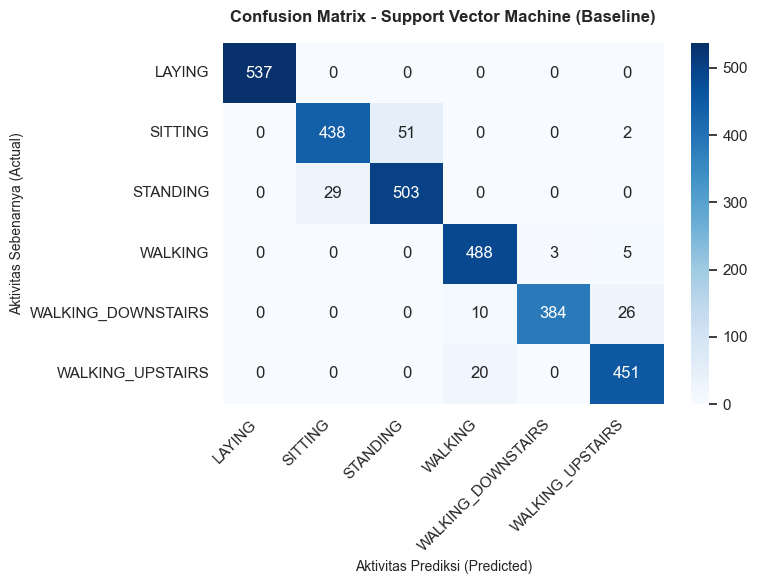

In [15]:
from sklearn.metrics import confusion_matrix

# Ambil prediksi dari model terbaik (SVM)
best_model_name = "Support Vector Machine (Baseline)"
y_pred_best = stored_predictions[best_model_name]

# Tulis manual labelnya sesuai urutan alphabet hasil mapping kemarin
class_labels = ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']

# Hitung matriksnya
cm = confusion_matrix(y_test, y_pred_best)

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)

plt.title(f'Confusion Matrix - {best_model_name}', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Aktivitas Prediksi (Predicted)', fontsize=10)
plt.ylabel('Aktivitas Sebenarnya (Actual)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
import joblib
import os

# Pastikan folder 'models' sudah dibuat
os.makedirs("../models", exist_ok=True)

# Looping untuk menyimpan semua model yang ada di dictionary
for name, model in models.items():
    # Ubah nama model jadi format file yang rapi (huruf kecil, spasi diganti underscore)
    filename = name.lower().replace(" ", "_").replace("-", "").replace("(", "").replace(")", "")
    model_path = f"../models/{filename}.pkl"
    
    # Simpan masing-masing model
    joblib.dump(model, model_path)
    print(f"📦 Model {name} berhasil disimpan ke: {model_path}")

print("\n🔥 Semua model (4 model) sukses diekspor ke folder 'models'!")

📦 Model K-Nearest Neighbors (Baseline) berhasil disimpan ke: ../models/knearest_neighbors_baseline.pkl
📦 Model Support Vector Machine (Baseline) berhasil disimpan ke: ../models/support_vector_machine_baseline.pkl
📦 Model Random Forest (Advanced Ensemble) berhasil disimpan ke: ../models/random_forest_advanced_ensemble.pkl
📦 Model XGBoost (Advanced Ensemble) berhasil disimpan ke: ../models/xgboost_advanced_ensemble.pkl

🔥 Semua model (4 model) sukses diekspor ke folder 'models'!


In [16]:
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import sklearn
import xgboost
import joblib

print(f"pandas=={pd.__version__}")
print(f"numpy=={np.__version__}")
print(f"matplotlib=={matplotlib.__version__}")
print(f"seaborn=={sns.__version__}")
print(f"scikit-learn=={sklearn.__version__}")
print(f"xgboost=={xgboost.__version__}")
print(f"joblib=={joblib.__version__}")

pandas==3.0.3
numpy==2.4.4
matplotlib==3.10.9
seaborn==0.13.2
scikit-learn==1.8.0
xgboost==3.3.0
joblib==1.5.3
